Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

**Book-image equivalent of `01-bayesian-optimization-demo.ipynb`, implemented without scikit-optimize.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import cho_factor, cho_solve
from scipy.stats import norm

In [2]:
noise_level = 0.1
objective_rng = np.random.RandomState(237)

def objective_without_noise(x):
    x = np.asarray(x)
    return np.sin(5 * x) * (1 - np.tanh(x ** 2))

def objective(x, noise_level=noise_level):
    return float(objective_without_noise(x)) + objective_rng.randn() * noise_level

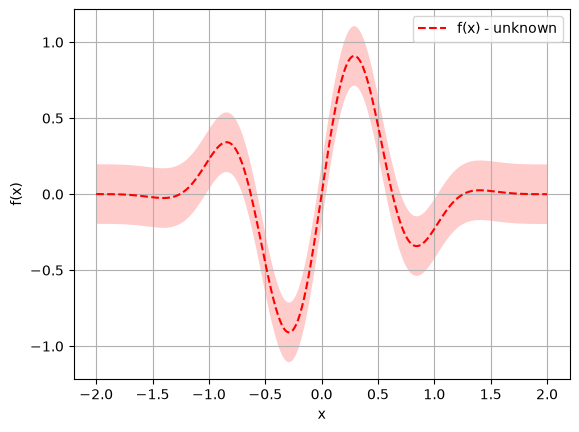

In [3]:
# Plot the unknown objective and its observation-noise interval.
x_grid = np.linspace(-2, 2, 400)
true_y = objective_without_noise(x_grid)

plt.plot(x_grid, true_y, 'r--', label='f(x) - unknown')
plt.fill_between(
    x_grid, true_y - 1.96 * noise_level, true_y + 1.96 * noise_level,
    alpha=0.2, color='r', edgecolor='none'
)
plt.legend()
plt.grid()
plt.ylabel('f(x)')
plt.xlabel('x')
plt.show()

In [4]:
# Minimal one-dimensional Gaussian process with a Matérn-5/2 kernel.
def matern52_kernel(x1, x2, length_scale=0.45):
    distance = np.abs(np.subtract.outer(np.ravel(x1), np.ravel(x2)))
    scaled = np.sqrt(5) * distance / length_scale
    return (1 + scaled + scaled ** 2 / 3) * np.exp(-scaled)

def gp_predict(x_observed, y_observed, x_query):
    kernel_observed = matern52_kernel(x_observed, x_observed)
    kernel_observed += (noise_level ** 2 + 1e-10) * np.eye(len(x_observed))
    factor = cho_factor(kernel_observed, lower=True, check_finite=False)
    cross_kernel = matern52_kernel(x_observed, x_query)
    mean = cross_kernel.T @ cho_solve(factor, y_observed, check_finite=False)
    solved = cho_solve(factor, cross_kernel, check_finite=False)
    variance = 1 - np.sum(cross_kernel * solved, axis=0)
    return mean, np.sqrt(np.maximum(variance, 1e-12))

def expected_improvement(mean, std, best_value):
    improvement = best_value - mean
    z = improvement / std
    return improvement * norm.cdf(z) + std * norm.pdf(z)

In [5]:
# Run the same style of noisy, expected-improvement Bayesian optimization.
optimizer_rng = np.random.RandomState(1234)
candidate_grid = np.linspace(-2, 2, 1000)
x_observed = list(optimizer_rng.uniform(-2, 2, size=2))
y_observed = [objective(value) for value in x_observed]

for _ in range(13):
    posterior_mean, posterior_std = gp_predict(
        np.array(x_observed), np.array(y_observed), candidate_grid
    )
    acquisition = expected_improvement(
        posterior_mean, posterior_std, np.min(y_observed)
    )
    distances = np.min(
        np.abs(candidate_grid[:, None] - np.array(x_observed)[None, :]), axis=1
    )
    acquisition[distances < 1e-6] = -np.inf
    next_x = candidate_grid[np.argmax(acquisition)]
    x_observed.append(next_x)
    y_observed.append(objective(next_x))

x_observed = np.asarray(x_observed)
y_observed = np.asarray(y_observed)

In [6]:
def plot_gp_sequence(show_objective=False, show_acquisition=False):
    fig, axes = plt.subplots(10, 1, figsize=(8, 30), sharex=True)

    for n_iter, ax in enumerate(axes):
        count = max(1, n_iter)
        observed_x = x_observed[:count]
        observed_y = y_observed[:count]
        mean, std = gp_predict(observed_x, observed_y, candidate_grid)

        if show_objective:
            ax.plot(candidate_grid, objective_without_noise(candidate_grid),
                    'r--', linewidth=1.5, label='f(x) - unknown')
        ax.plot(candidate_grid, mean, color='green', linewidth=1.5,
                label='Gaussian process mean')
        ax.fill_between(candidate_grid, mean - 1.96 * std, mean + 1.96 * std,
                        color='green', alpha=0.2, label='95% interval')
        ax.plot(observed_x, observed_y, 'r.', markersize=10, label='observations')

        if show_acquisition:
            acquisition = expected_improvement(mean, std, np.min(observed_y))
            scaled_acquisition = acquisition / max(acquisition.max(), 1e-12)
            lower, upper = ax.get_ylim()
            ax.plot(candidate_grid, lower + 0.2 * (upper - lower) * scaled_acquisition,
                    color='navy', linewidth=1, label='expected improvement')
            next_x = candidate_grid[np.argmax(acquisition)]
            ax.axvline(next_x, color='navy', linestyle=':', linewidth=1,
                       label='next point')

        if n_iter == 0:
            ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_ylabel('')
        ax.set_xlabel('')

    fig.tight_layout()
    plt.show()

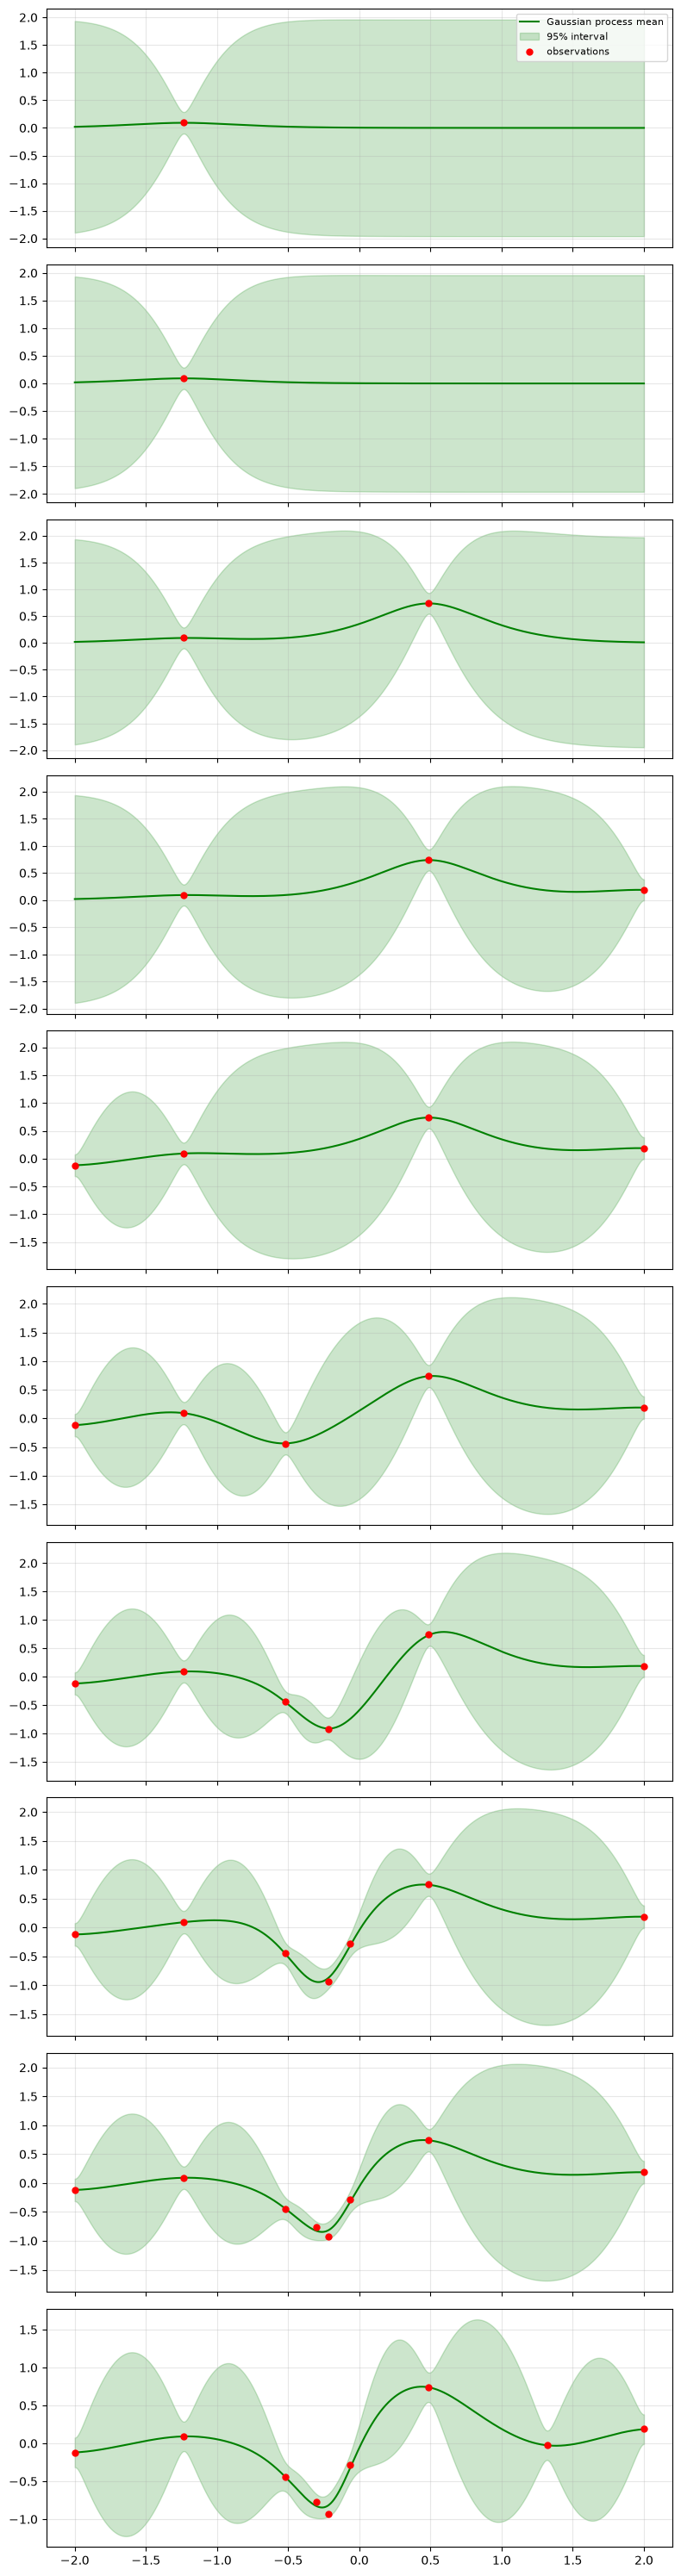

In [7]:
# Equivalent of the posterior-only skopt figure.
plot_gp_sequence(show_objective=False, show_acquisition=False)

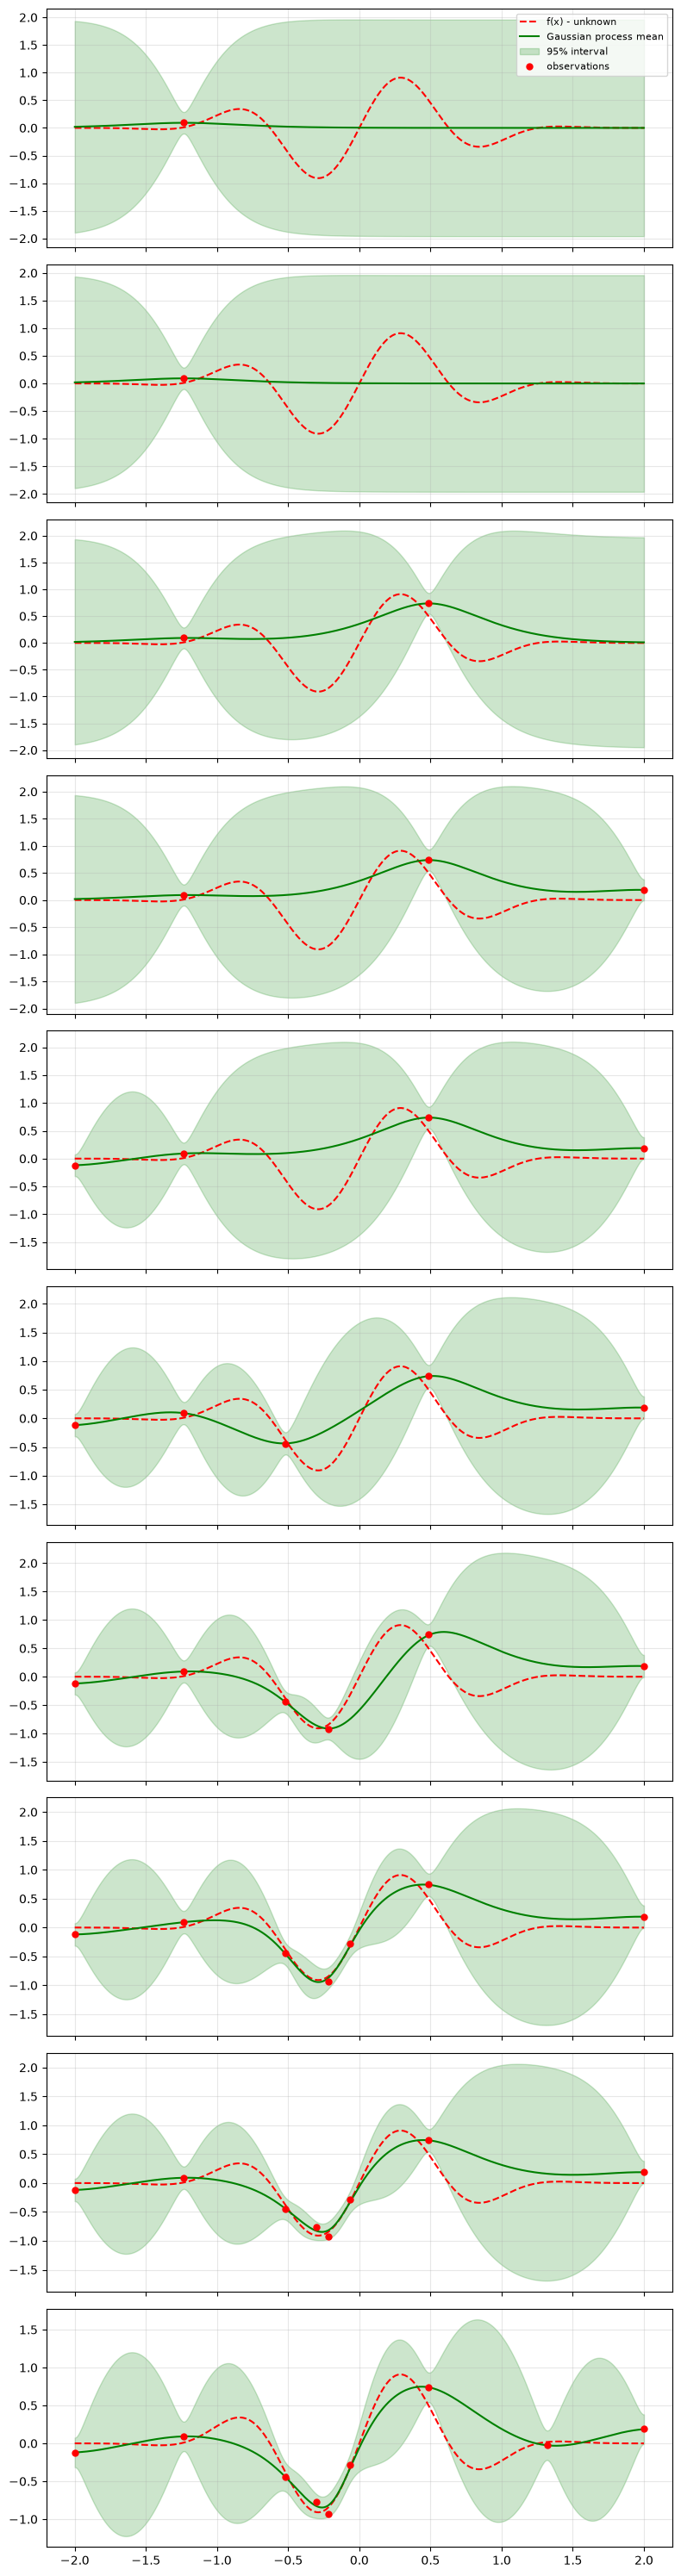

In [8]:
# Equivalent with the true objective overlaid.
plot_gp_sequence(show_objective=True, show_acquisition=False)

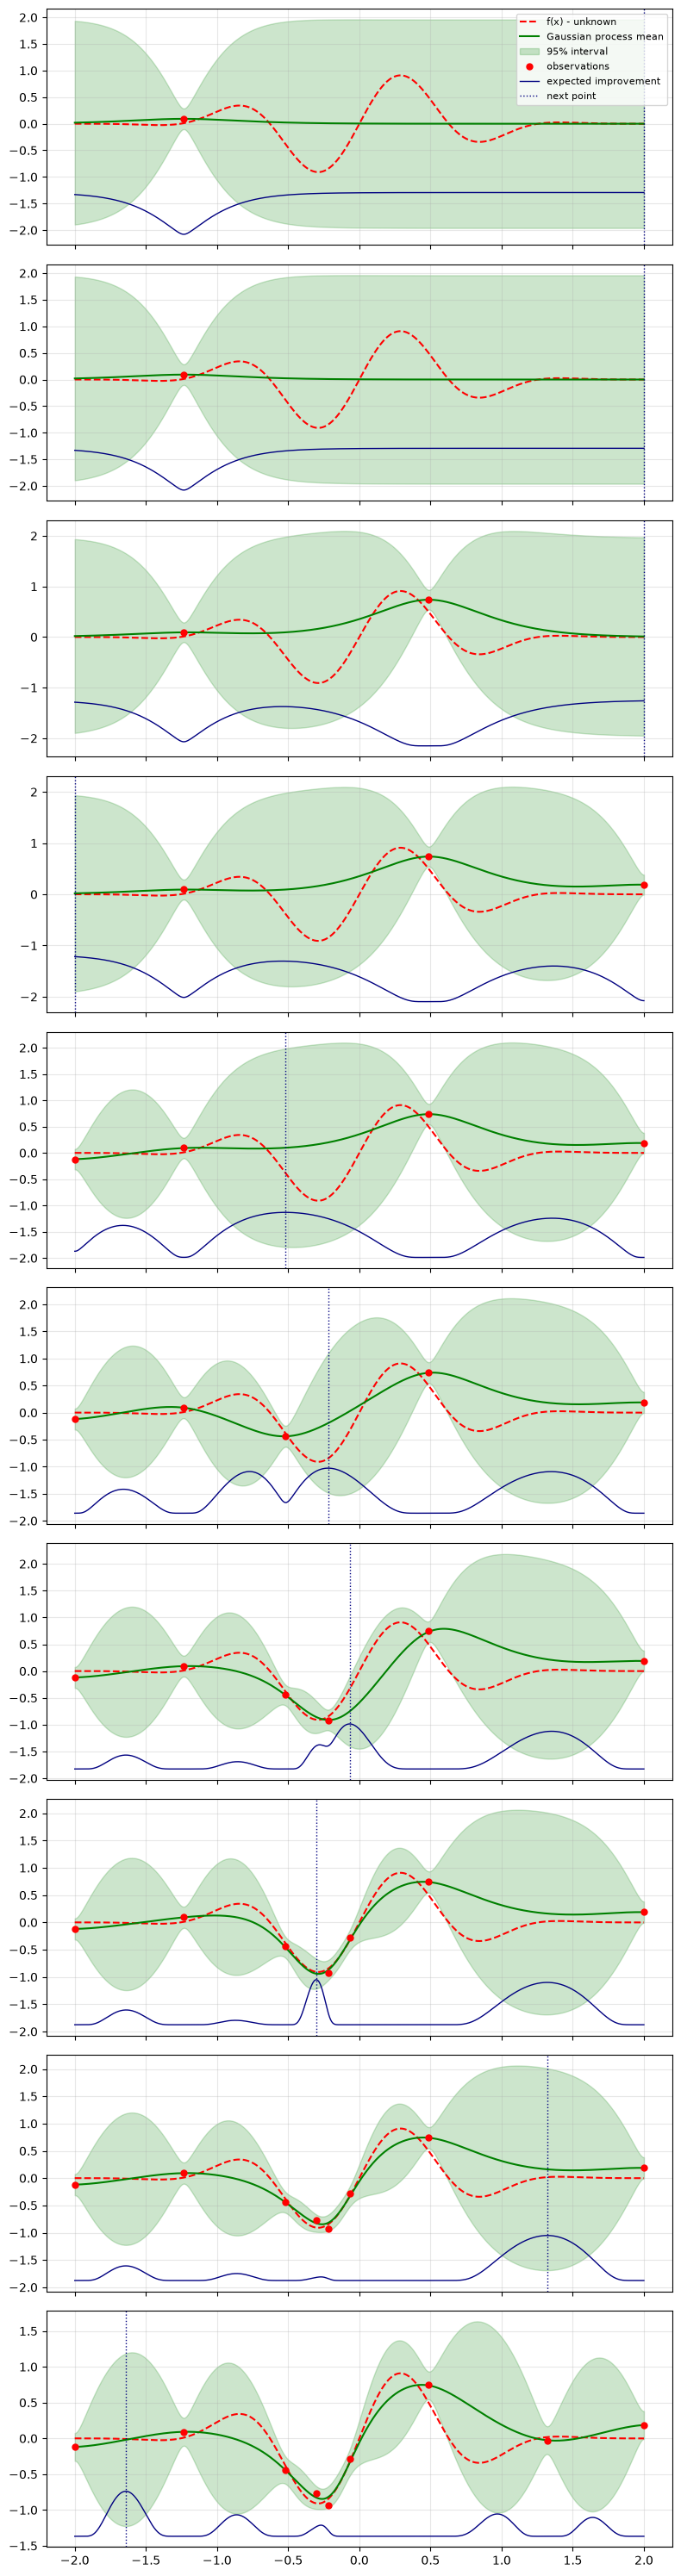

In [9]:
# Equivalent with expected improvement and the proposed next point.
plot_gp_sequence(show_objective=True, show_acquisition=True)